### Finite square well

Let's solve the time-independent Schrodinger equation:

$$
    \left[ - \frac{\hbar ^ 2}{2 m} \frac{d ^ 2}{d x ^ 2} (*) + V(x) \right] \psi(x) = E \, \psi(x)
$$

For a finite square well:

\begin{equation*}
    V (x) := \begin{cases}
            - V_0 \quad \text{for} \quad | x | \leq a  \\
            0 \quad \text{elsewhere}
            \end{cases}
\end{equation*}

Looking for bound states ($0 < E < - V_0$). We can write this equation in a dimensionless form by defining:

$$
    x' := x / a \quad V' := V(x') / \frac{\hbar ^ 2}{2 m a ^ 2} \quad E' := E / \frac{\hbar ^ 2}{2 m a ^ 2}
$$

Getting:

$$
    \left[ - \frac{d ^ 2}{d x ^ {'2}} (*) + V'(x') \right] \psi(x') = E' \, \psi(x')
$$

But now we've this potential:

\begin{equation*}
    V'(x') =    \begin{cases}
                    - V_0 / \frac{\hbar ^ 2}{2 m a ^ 2} := - V_0' \quad \text{for} \quad | x' | \leq 1  \\
                    0 \quad \text{elsewhere}
                \end{cases}
\end{equation*}

Let's solve the problem using a computational approach

In [1]:
# Importing libraries
import numpy as np
from scipy.linalg import eigh_tridiagonal
from scipy.integrate import trapezoid
import matplotlib.pyplot as plt

In [2]:
# Solve & Plot function
def solve_and_plot_quantum_well(V0_prime, x_range = (-5, 5), N = 100_000, plot = True):

    xmin, xmax = x_range

    # Discretize the space
    x_prime = np.linspace(xmin, xmax, N)
    delta = x_prime[1] - x_prime[0]
    
    # Define potential (square well from -1 to 1)
    V_prime = np.where(np.abs(x_prime) <= 1, -V0_prime, 0)
    
    # Set up tridiagonal matrix
    d = 2 / (delta ** 2) + V_prime
    d_below_above = -1 / (delta ** 2) * np.ones(N - 1)
    
    # Solve for eigenvalues and eigenvectors
    energy_prime, eigenfunctions = eigh_tridiagonal(
        d = d, e = d_below_above, 
        eigvals_only = False, 
        select = 'v', 
        select_range = (- V0_prime, 0)
    )
    
    # Normalize wavefunctions
    for i in range(eigenfunctions.shape[1]):
        norm = np.sqrt(trapezoid(eigenfunctions[:, i] ** 2, x_prime))
        eigenfunctions[:, i] /= norm
    
    # Transpose to shape (n_states, N)
    eigenfunctions = eigenfunctions.T
    
    # Create plots if requested
    if plot:
        # Create one figure with three plots in a row
        plt.figure(figsize = (15, 5))
        
        # Plot 1: Potential and energy levels
        plt.subplot(1, 3, 1)
        plt.plot(x_prime, V_prime, 'k-', linewidth = 2, label = 'Potential')
        
        # Plot energy levels
        colors = ['red', 'blue', 'green', 'orange', 'purple']
        for i, energy in enumerate(energy_prime):
            color = colors[i % len(colors)]
            plt.axhline(y = energy, color = color, linestyle = '--', linewidth = 1.5, 
                       alpha = 0.7, label = f'$E_{{{i}}}′$ = {energy:.3f}')
        
        plt.xlabel(r"$x′$")
        plt.ylabel(r"$V′(x′), E′$")
        plt.title('Finite Square Well Bound States')
        plt.grid(True, alpha = 0.5)
        plt.xlim(xmin / 2, xmax / 2)
        plt.axvline(x = -1, color = 'gray', linestyle = ':', alpha = 0.7)
        plt.axvline(x = 1, color = 'gray', linestyle = ':', alpha = 0.7)
        plt.legend(loc = 'best', fontsize = 9)
        
        # Plot 2: Wavefunctions
        plt.subplot(1, 3, 2)
        
        for i, energy in enumerate(energy_prime):
            color = colors[i % len(colors)]
            plt.plot(x_prime, eigenfunctions[i], linewidth = 1.5, color = color, 
                    label = f'$\\psi_{{{i}}}(x′)$')
        
        plt.xlabel(r"$x′$")
        plt.ylabel(r"$\psi(x′)$")
        plt.title('Bound State Wavefunctions')
        plt.grid(True, alpha = 0.5)
        plt.xlim(xmin / 2, xmax / 2)
        plt.axvline(x = -1, color = 'gray', linestyle = ':', alpha = 0.7)
        plt.axvline(x = 1, color = 'gray', linestyle = ':', alpha = 0.7)
        plt.legend(loc = 'best', fontsize = 9)
        
        # Plot 3: Probability densities
        plt.subplot(1, 3, 3)
        
        for i, energy in enumerate(energy_prime):
            color = colors[i % len(colors)]
            # Plot probability density
            plt.plot(x_prime, eigenfunctions[i] ** 2, linewidth = 1.5, 
                    color = color, label = f'$|\\psi_{{{i}}}(x′)|^2$')
        
        plt.xlabel(r"$x′$")
        plt.ylabel(r"$|\psi(x′)|^2$")
        plt.title('Probability Densities')
        plt.grid(True, alpha = 0.5)
        plt.legend(loc = 'best', fontsize = 9)
        plt.xlim(xmin / 2, xmax / 2)
        plt.axvline(x = -1, color = 'gray', linestyle = ':', alpha = 0.7)
        plt.axvline(x = 1, color = 'gray', linestyle = ':', alpha = 0.7)
        
        plt.tight_layout()
        plt.show()
        
        # Print results
        print(f"Found {len(energy_prime)} bound states:")
        for i, energy in enumerate(energy_prime):
            print(f"  State {i}: E′ = {energy:.3f}")
    
        return None
    
    else: return (x_prime, energy_prime, eigenfunctions)

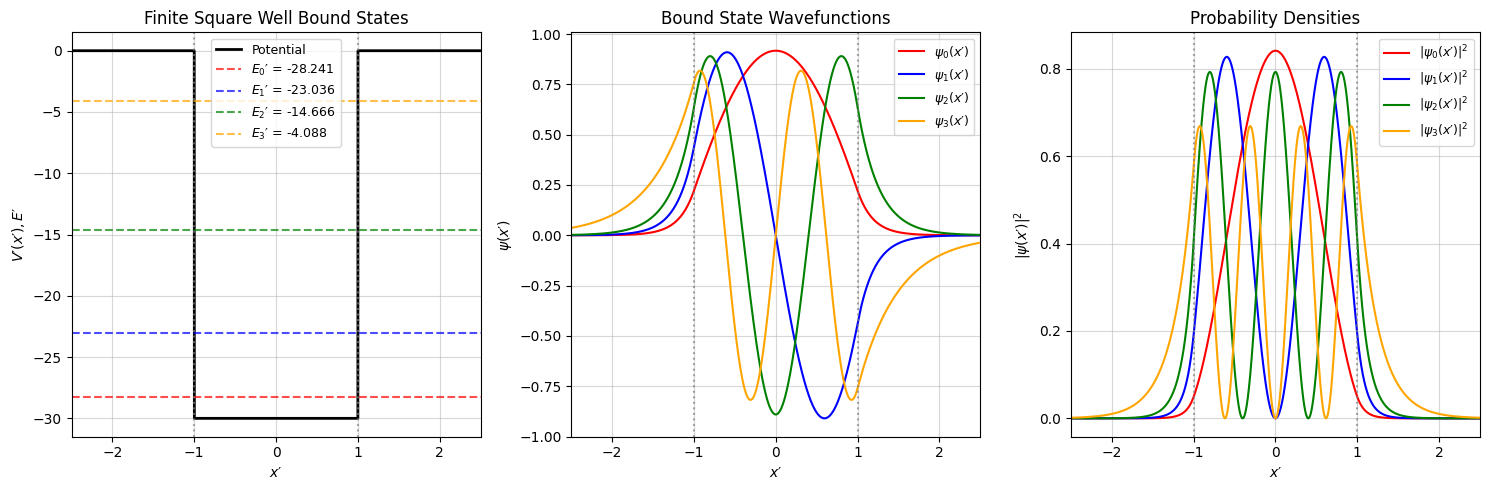

Found 4 bound states:
  State 0: E′ = -28.241
  State 1: E′ = -23.036
  State 2: E′ = -14.666
  State 3: E′ = -4.088


In [3]:
# V0 = 30 * [hbar ^ 2 / (2 m a ^ 2)] 
V0_prime = 30
solve_and_plot_quantum_well(V0_prime)

In [4]:
# Computing the escape probability (tunnel effect) at time t = 0
x_prime, e_prime, f_prime = solve_and_plot_quantum_well(V0_prime, plot = False)

for j in range(len(e_prime)):
    print("Tunneling effect probability:", round(100 * (trapezoid(f_prime[j][x_prime > 1] ** 2, x_prime[x_prime > 1]) + trapezoid(f_prime[j][x_prime <= - 1] ** 2, x_prime[x_prime <= - 1])), 2), "%")

Tunneling effect probability: 0.93 %
Tunneling effect probability: 4.0 %
Tunneling effect probability: 10.58 %
Tunneling effect probability: 28.58 %
